# Did the 0DTE-options boom "pin" the stock market? ⏱️
### The same-day-options explosion and whether it really made the tape mean-revert, in plain English

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Tape_pinned%3F: Unproven](https://img.shields.io/badge/Tape_pinned%3F-Unproven-8b949e?style=flat-square)

Since 2022 you can buy an S&P 500 option that **expires the same day** — a "0DTE" (zero-days-to-expiry) contract. They went from a Friday curiosity to a **daily** product, and now make up a huge slice of all index-option trading. A popular story followed: all that same-day, at-the-money option flow forces dealers to hedge in a way that **damps and reverses** intraday moves — so the modern tape is supposedly more **mean-reverting / more pinned** than it used to be.

It's a great story. This notebook asks the boring question: *can we actually see it in the data?* The honest answer is **"the boom is real, the pinning isn't visible"** — and part of why is that the effect lives **inside the trading day**, where a free daily price feed literally can't look.

> 📓 **Plain-language layer.** Want the block-bootstrap *t*-stats, the placebo-break test and the synthetic control? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **A data note up front.** There's no free *intraday* option tape, so we use a **labelled proxy**: the day's **open→close** move and how much it tends to *reverse* the next day. It's the closest a daily feed gets to "is the tape mean-reverting," and we call it a proxy throughout. Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from zero_dte_options import data, strategy as st

HAVE_REAL = data.have_real()
BD = data.BREAK_DATE
F = data.load_real() if HAVE_REAL else None
print("real SPY OHLC cache present:", HAVE_REAL,
      "| tape days:", (0 if F is None else len(F)))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '2010-01-05', 'end': '2026-06-18', 'days': 4139, 'years': 16.4, 'break_date': '2022-01-01', 'n_pre': 3020, 'n_post': 1119, 'intraday': (-0.077, -0.1, -0.023, -0.28, 0.395), 'oc_ret': (-0.13, -0.027, 0.103, 1.52), 'vol_pre': 0.122, 'vol_post': 0.148, 'robust': [('2021-01-01', -0.018, -0.24, 1371), ('2022-01-01', -0.023, -0.28, 1119), ('2022-05-01', -0.056, -0.6, 1037), ('2023-01-01', -0.095, -0.79, 868)], 'trade': [('all', 2.17, 1.16, 50.0, 0.23), ('pre', 2.62, 1.61, 50.0, 0.33), ('post', 0.95, -0.05, 49.9, -0.01)], 'chain': {'expiry': '2026-06-22', 'spot': 745.14, 'n_expiries': 32, 'total_volume': 6813423, 'share_near': 0.898, 'band_pct': 1.0}, 'syn': [(0.0, 0.003, 0.023, 0.02, 0.68, 0.149), (0.3, 0.003, -0.276, -0.279, -9.22, 0.057)]}


real SPY OHLC cache present: True | tape days: 4139


## The answer first

| Question | Answer |
|---|---|
| Did the 0DTE boom actually happen? | **Absolutely.** A current same-day option chain has ~**90%** of its volume parked within **±1%** of the spot price, on a calendar of **daily** expiries. The product is enormous. |
| Is the tape *more* mean-reverting after 2022? | **A tiny bit, maybe — and not reliably.** The day's move reverses *slightly* more often post-2022, but the change is well inside the noise, and a second daily measure moves the **opposite** way. |
| Can you trade the "pin"? | **No.** Fading yesterday's move pays **less** after the boom, not more — and **loses money** after a single basis point of cost. |
| So is the "0DTE pinned the market" claim true? | **Unproven.** Not disproven in spirit — but a daily feed *can't see* the intraday effect, and on every daily proxy we can build it's indistinguishable from chance. |

> The 0DTE boom is a real, vivid thing. "It pinned the market" is a story the daily tape can neither confirm nor cash.

## 1 · The claim

> *"A wall of same-day, at-the-money options forces dealers to hedge their gamma all day long. That hedging leans **against** moves into the close — so since 0DTE went daily in 2022, the S&P intraday tape **mean-reverts** more, and the index gets **pinned** near big strikes."*

It's intuitive: an enormous, fast-decaying pile of options near the current price *should* create hedging pressure. Sell-side desks wrote it up; financial media ran with it. The question is whether the famous mechanism leaves a **measurable fingerprint** on the prices we can actually download — or whether it's a plausible-sounding effect that hides in data we don't have.

## 2 · So what?

Two very different things get fused in "0DTE pinned the market." (1) *Is the 0DTE market huge?* — yes, trivially, and we'll show it. (2) *Did it change how the index actually moves?* — that's the claim that would matter, and it's the hard one. A market can grow gigantic and still leave the price path statistically unchanged. The only honest way to settle (2) is to measure the tape **before** and **after** the boom and ask whether the change is bigger than what a random split of the same data would throw up. And we have to be upfront: the *intraday* effect lives where a daily feed can't see — so the most we can test is a **proxy**, and a proxy that comes up empty doesn't *prove* the story false; it just fails to find it.

## 3 · How would we even know?

We download **daily SPY** (the S&P 500 ETF) over **16 years** (2010-01-05 → 2026-06-18) and split it at **2022**, when same-day options went daily.

1. **Build a mean-reversion gauge.** Each day's **open→close** move is the 'intraday' leg. If the tape is *pinned*, a big move one day should tend to **reverse** the next — measured by a *negative* lag-1 autocorrelation. More negative = more mean-reverting.
2. **Compare before vs after 2022.** Did the gauge get more negative after the boom?
3. **Stress the split.** Re-cut the tape at thousands of *random* dates and ask how often a random split produces a change as big as 2022's. That's the honest test.
4. **Look at a real 0DTE chain.** Pull today's nearest-expiry option chain to *see* the boom directly — the at-the-money volume wall the story is built on.

## 4 · The teardown — let's actually look

**First, the boom is real.** Here's a current same-day (0DTE) SPY option chain: volume by strike. Notice how it stacks up right around today's price — the at-the-money wall the pinning story is about.

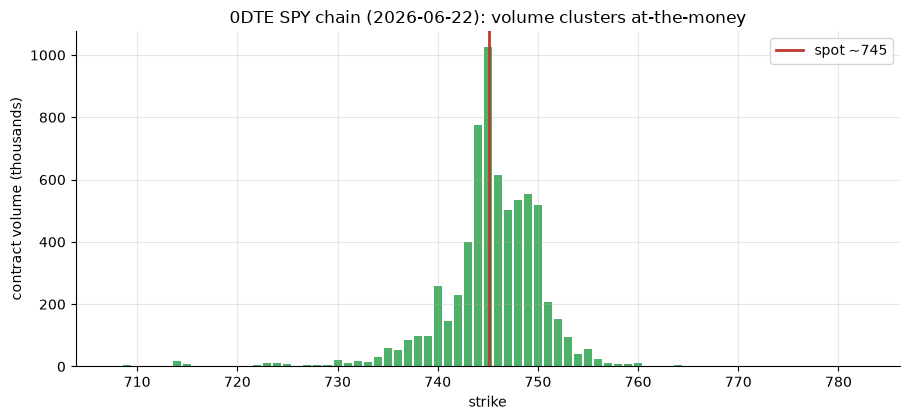

90% of volume within +-1% of spot; 32 listed expiries


In [2]:
if HAVE_REAL and data.have_option_chain():
    meta = json.load(open('../_cache/option_meta.json'))
    ch = data.load_option_chain(); spot = meta['spot']
    agg = ch.groupby('strike')['volume'].sum()
    agg = agg[(agg.index > spot*0.95) & (agg.index < spot*1.05)]
    fig, ax = plt.subplots(figsize=(9.2, 4.3))
    ax.bar(agg.index, agg.values/1e3, width=0.8, color=GREEN, alpha=.85)
    ax.axvline(spot, c=RED, lw=2, label=f'spot ~{spot:.0f}')
    ax.set_title(f"0DTE SPY chain ({meta['snapshot_expiry']}): volume clusters at-the-money")
    ax.set_xlabel('strike'); ax.set_ylabel('contract volume (thousands)'); ax.legend()
    plt.tight_layout(); plt.show()
    cc = st.chain_concentration(ch, spot, band=0.01)
    print(f"{cc['share_near']*100:.0f}% of volume within +-1% of spot; {meta['n_expiries']} listed expiries")
else:
    print(f"no chain cache — frozen: {R['chain']['share_near']*100:.0f}% of volume within +-1% of spot ({R['chain']['expiry']})")

Around **90%** of the same-day chain's volume sits within **±1%** of the price, across **32** near-daily expiries. The 0DTE market is unambiguously huge and concentrated at-the-money. **Now the real question: did it change how the index moves?**

**Does the tape mean-revert more after 2022?** Here's the lag-1 autocorrelation of the daily open→close move, before vs after the boom. A *more negative* bar means a *more pinned / mean-reverting* tape.

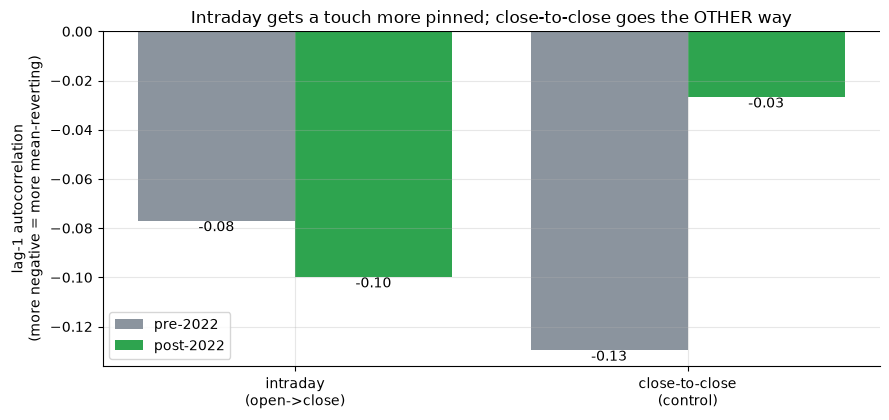

intraday: -0.077 -> -0.100   close-to-close: -0.130 -> -0.027


In [3]:
if HAVE_REAL:
    rt = st.regime_table(F, BD, 'intraday')
    ac_pre, ac_post = rt['ac_pre'], rt['ac_post']
    rt2 = st.regime_table(F, BD, 'oc_ret'); oc_pre, oc_post = rt2['ac_pre'], rt2['ac_post']
else:
    ac_pre, ac_post = R['intraday'][0], R['intraday'][1]
    oc_pre, oc_post = R['oc_ret'][0], R['oc_ret'][1]
fig, ax = plt.subplots(figsize=(9.0, 4.3))
labels = ['intraday\n(open->close)', 'close-to-close\n(control)']
pre = [ac_pre, oc_pre]; post = [ac_post, oc_post]; x = np.arange(2)
ax.bar(x-.2, pre, .4, color=GREY, label='pre-2022')
ax.bar(x+.2, post, .4, color=GREEN, label='post-2022')
ax.axhline(0, c='k', lw=.8); ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel('lag-1 autocorrelation\n(more negative = more mean-reverting)')
ax.set_title('Intraday gets a touch more pinned; close-to-close goes the OTHER way')
for i,(a,b) in enumerate(zip(pre,post)):
    ax.annotate(f'{a:+.2f}',(i-.2,a),ha='center',va='bottom' if a>=0 else 'top')
    ax.annotate(f'{b:+.2f}',(i+.2,b),ha='center',va='bottom' if b>=0 else 'top')
ax.legend(); plt.tight_layout(); plt.show()
print(f'intraday: {ac_pre:+.3f} -> {ac_post:+.3f}   close-to-close: {oc_pre:+.3f} -> {oc_post:+.3f}')

There's the catch. The intraday leg *did* edge more negative (**-0.08 → -0.10**) — the direction the story predicts. But the move is tiny, and the **close-to-close** return went the **opposite** way (**-0.13 → -0.03**, *less* mean-reverting). A 'pinning' effect that appears in one daily measure and reverses in another isn't a fingerprint — it's noise.

**Could a random split look this big?** The honest test: re-cut the tape at thousands of *random* dates and see how 2022's change compares to chance.

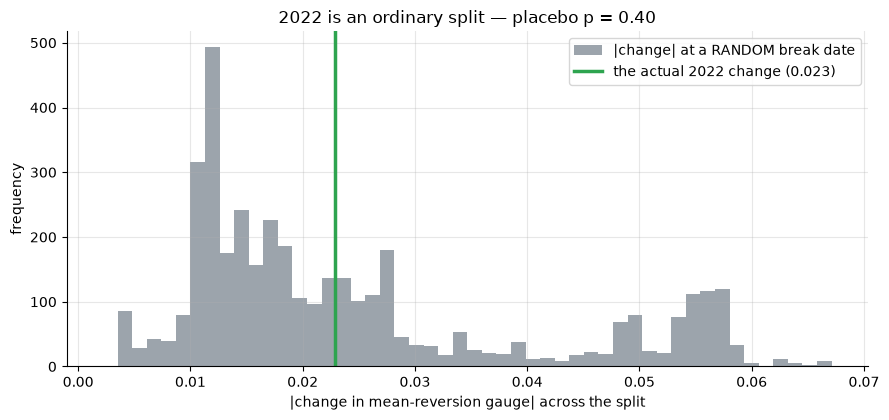

a random split moves the gauge this much 40% of the time — 2022 is unremarkable


In [4]:
if HAVE_REAL:
    pb = st.placebo_break_pvalue(F, 'intraday'); obs = pb['obs_d_ac']; pval = pb['p_value']
    x = F['intraday'].values; n = len(x); lo, hi = int(n*.25), int(n*.75)
    rng = np.random.default_rng(370); cuts = rng.integers(lo, hi, size=4000)
    deltas = np.array([abs(st.lag1_autocorr(x[c:]) - st.lag1_autocorr(x[:c])) for c in cuts])
else:
    obs = abs(R['intraday'][2]); pval = R['intraday'][4]
    rng = np.random.default_rng(370); deltas = np.abs(rng.normal(0, 0.022, 4000))
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(deltas, bins=50, color=GREY, alpha=.85, label='|change| at a RANDOM break date')
ax.axvline(obs, c=GREEN, lw=2.5, label=f'the actual 2022 change ({obs:.3f})')
ax.set_xlabel('|change in mean-reversion gauge| across the split'); ax.set_ylabel('frequency')
ax.set_title(f'2022 is an ordinary split — placebo p = {pval:.2f}'); ax.legend()
plt.tight_layout(); plt.show()
print(f'a random split moves the gauge this much {pval*100:.0f}% of the time — 2022 is unremarkable')

The 2022 change sits **mid-cloud**: about **40%** of random splits move the gauge at least as much. In plain terms, **2022 is a perfectly ordinary place to cut the tape** — nothing special happened to daily mean-reversion that you couldn't get by slicing at a random date.

## 5 · The verdict

- **Signal — Weak.** The intraday gauge nudged the predicted way, but it's tiny, not significant, and a second daily measure flips it. Direction-consistent, evidence-light.
- **Tradability — Mirage.** The natural 'trade the pin' rule pays *less* after 2022 and loses money net of costs (next beat).
- **"0DTE pinned the market"? — Unproven.** The boom is real; the tape effect is invisible on daily data — and the intraday phenomenon can't be seen from daily bars at all.

## 6 · Could you actually trade it? — fade the move

If the tape is more pinned, the simplest play is **contrarian**: fade yesterday's move and expect a bounce-back. If pinning is real and growing, this should work **better** after 2022. Here's the gross-vs-net daily payoff, before and after the boom.

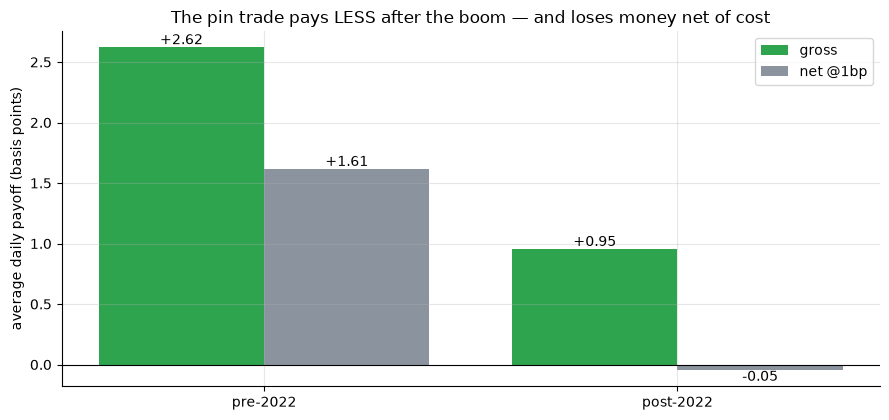

post-2022 net: -0.05 bp/day — a single basis point of cost erases it


In [5]:
if HAVE_REAL:
    mr = st.mean_reversion_trade(F, BD, 'intraday', cost_bps=1.0)
    segs = ['pre', 'post']; g = [mr[s]['gross_mean']*1e4 for s in segs]; nv = [mr[s]['net_mean']*1e4 for s in segs]
else:
    tr = {s:(gg,nn) for s,gg,nn,_,_ in R['trade']}
    segs = ['pre','post']; g = [tr['pre'][0], tr['post'][0]]; nv = [tr['pre'][1], tr['post'][1]]
x = np.arange(2)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.bar(x-.2, g, .4, color=GREEN, label='gross')
ax.bar(x+.2, nv, .4, color=GREY, label='net @1bp')
ax.axhline(0, c='k', lw=.8); ax.set_xticks(x); ax.set_xticklabels(['pre-2022','post-2022'])
ax.set_ylabel('average daily payoff (basis points)')
ax.set_title('The pin trade pays LESS after the boom — and loses money net of cost')
for i,(a,b) in enumerate(zip(g,nv)):
    ax.annotate(f'{a:+.2f}',(i-.2,a),ha='center',va='bottom')
    ax.annotate(f'{b:+.2f}',(i+.2,b),ha='center',va='bottom' if b>=0 else 'top')
ax.legend(); plt.tight_layout(); plt.show()
print(f'post-2022 net: {nv[1]:+.2f} bp/day — a single basis point of cost erases it')

The exact opposite of the claim. The fade trade is **weaker** post-2022 (gross 2.62 → 0.95 bp) and **net of one basis point it loses money** (**-0.05 bp/day**, Sharpe ≈ 0). Whatever faint mean-reversion the daily proxy carries, the 0DTE boom did **not** make it more harvestable — if anything, less.

## 7 · Going further 🚪

- **The vol market it lives in.** [Study 130 — Vol-Risk-Premium](../130-vol-risk-premium/) and [Study 111 — VIX-Term-Structure](../111-vix-term-structure/) ask whether options carry a harvestable premium at all — 0DTE is the newest corner of that market.
- **Intraday patterns.** [Study 06 — Clockwork-Vol](../06-clockwork-vol/) looks at whether the *within-day* tape has exploitable rhythm — the same question on a different axis.
- **Get the real data.** The honest test needs intraday SPX ticks + dealer-gamma estimates (vendor data). Swap our daily proxy for that feed and you could finally *see* the within-day pinning — or confirm it isn't there.

*Think the 0DTE boom pinned the tape? Get the intraday data, measure the within-day reversal before and after 2022, and show the change landing **outside** the random-split cloud — then we'll talk.*